# Exoplanet Habitability Classification - ML Pipeline

This notebook builds and evaluates machine learning models to classify exoplanets as habitable or non-habitable.

## Key Features:
- SMOTE for handling class imbalance (mild to prevent overfitting)
- Regularization in all models
- 5-fold cross-validation for robust evaluation
- Ensemble voting classifier

In [19]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, 
    confusion_matrix, classification_report, precision_recall_curve,
    roc_curve
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Define paths - use relative paths for portability
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'preprocessed.csv')
MODELS_PATH = os.path.join(PROJECT_ROOT, 'models')

# Create models directory if it doesn't exist
os.makedirs(MODELS_PATH, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"Models path: {MODELS_PATH}")

Project root: c:\Users\konal\OneDrive\Documents\GitHub\B13-ExoHabitAI
Data path: c:\Users\konal\OneDrive\Documents\GitHub\B13-ExoHabitAI\data\processed\preprocessed.csv
Models path: c:\Users\konal\OneDrive\Documents\GitHub\B13-ExoHabitAI\models


## 1. Data Loading

In [20]:
# Load the preprocessed data
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (6100, 34)

Column names:
['planet_name', 'host_star_name', 'radius_earth', 'pl_radj', 'mass_earth', 'pl_massj', 'orbital_period', 'semimajor_axis', 'eq_temp_k', 'density', 'star_temp_k', 'star_luminosity', 'star_metallicity', 'star_spectype', 'habitability_score', 'stellar_compatibility', 'orbital_stability', 'star_A', 'star_B', 'star_F', 'star_G', 'star_K', 'star_M', 'star_Unknown', 'radius_earth_scaled', 'mass_earth_scaled', 'orbital_period_scaled', 'semimajor_axis_scaled', 'eq_temp_k_scaled', 'density_scaled', 'star_temp_k_scaled', 'star_luminosity_scaled', 'star_metallicity_scaled', 'habitable_binary']

First few rows:


,planet_name,host_star_name,radius_earth,pl_radj,mass_earth,pl_massj,orbital_period,semimajor_axis,eq_temp_k,density,...,radius_earth_scaled,mass_earth_scaled,orbital_period_scaled,semimajor_axis_scaled,eq_temp_k_scaled,density_scaled,star_temp_k_scaled,star_luminosity_scaled,star_metallicity_scaled,habitable_binary
0,11 Com b,11 Com,2.42,0.215898,196.050555,0.617,323.21000,1.178,811.0,1.33,...,0.0,0.000000,10.220065,5.369859,0.0,0.0,-0.768936,2.00510,-1.142857,0
1,11 UMi b,11 UMi,2.42,0.215898,196.050555,0.617,516.21997,1.530,811.0,1.33,...,0.0,0.000000,16.539934,7.129485,0.0,0.0,-1.491933,0.00000,0.000000,0
2,14 And b,14 And,2.42,0.215898,196.050555,0.617,186.76000,0.775,811.0,1.33,...,0.0,0.000000,5.752181,3.355287,0.0,0.0,-0.753623,1.86679,-0.904762,0
3,14 Her b,14 Her,2.42,0.215898,2559.472162,8.053,1765.03890,2.774,811.0,1.33,...,0.0,2363.421607,57.430941,13.348164,0.0,0.0,0.000000,0.00000,0.000000,0
4,16 Cyg B b,16 Cyg B,2.42,0.215898,196.050555,0.617,798.50000,1.660,811.0,1.33,...,0.0,0.000000,25.782839,7.779347,0.0,0.0,0.189226,0.00000,0.380952,0


## 2. Data Exploration

In [21]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check class distribution
print("\nTarget variable distribution:")
print(df['habitable_binary'].value_counts())
print(f"\nClass imbalance ratio: {df['habitable_binary'].value_counts()[0] / df['habitable_binary'].value_counts()[1]:.2f}:1")

Missing values per column:
planet_name                0
host_star_name             0
radius_earth               0
pl_radj                    0
mass_earth                 0
pl_massj                   0
orbital_period             0
semimajor_axis             0
eq_temp_k                  0
density                    0
star_temp_k                0
star_luminosity            0
star_metallicity           0
star_spectype              0
habitability_score         0
stellar_compatibility      0
orbital_stability          0
star_A                     0
star_B                     0
star_F                     0
star_G                     0
star_K                     0
star_M                     0
star_Unknown               0
radius_earth_scaled        0
mass_earth_scaled          0
orbital_period_scaled      0
semimajor_axis_scaled      0
eq_temp_k_scaled           0
density_scaled             0
star_temp_k_scaled         0
star_luminosity_scaled     0
star_metallicity_scaled    0
habitable_binary

## 3. Feature Selection

In [22]:
# Define columns to drop (IDs, target, and leakage sources)
drop_cols = [
    'planet_name', 'host_star_name', 'star_spectype', 
    'habitable_binary', 
    'habitability_score', 'stellar_compatibility', 'orbital_stability'
]

# Select features: scaled columns + star flags
X_cols = [c for c in df.columns if '_scaled' in c or 'star_' in c]
X_cols = [c for c in X_cols if c not in drop_cols]

X = df[X_cols]
y = df['habitable_binary']

print(f"Number of features: {len(X_cols)}")
print(f"Features: {X_cols}")

Number of features: 19
Features: ['star_temp_k', 'star_luminosity', 'star_metallicity', 'star_A', 'star_B', 'star_F', 'star_G', 'star_K', 'star_M', 'star_Unknown', 'radius_earth_scaled', 'mass_earth_scaled', 'orbital_period_scaled', 'semimajor_axis_scaled', 'eq_temp_k_scaled', 'density_scaled', 'star_temp_k_scaled', 'star_luminosity_scaled', 'star_metallicity_scaled']


## 4. Feature Engineering: Stellar Flux

In [23]:
# Create stellar flux feature (if not already present)
# Stellar flux = Luminosity / Distance^2 (represents energy reaching the planet)
if 'stellar_flux' not in df.columns:
    df['stellar_flux'] = (10**df['star_luminosity']) / (df['semimajor_axis']**2)
    
    # Also create scaled version
    scaler = StandardScaler()
    df['stellar_flux_scaled'] = scaler.fit_transform(df[['stellar_flux']])
    
    # Add to features
    X_cols.append('stellar_flux_scaled')
    X = df[X_cols]

print(f"Updated feature count: {len(X_cols)}")

Updated feature count: 20


## 5. Train-Test Split

In [24]:
# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"\nTraining class distribution:")
print(y_train.value_counts())
print(f"\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 4880
Testing samples: 1220

Training class distribution:
habitable_binary
0    4858
1      22
Name: count, dtype: int64

Testing class distribution:
habitable_binary
0    1215
1       5
Name: count, dtype: int64


## 6. Handling Class Imbalance with SMOTE (Mild)

In [25]:
# Apply mild SMOTE to handle class imbalance without overfitting
# Target: make minority class 30% of majority (instead of 100%)
class_counts = y_train.value_counts()
sampling_strategy = {0: class_counts[0], 1: int(class_counts[0] * 0.3)}

smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=sampling_strategy)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE - Training samples: {len(X_train)}")
print(f"After SMOTE - Training samples: {len(X_train_res)}")
print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())

Before SMOTE - Training samples: 4880
After SMOTE - Training samples: 6315

Class distribution after SMOTE:
habitable_binary
0    4858
1    1457
Name: count, dtype: int64


## 7. Feature Scaling

In [26]:
# Scale features for models that benefit from scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Save scaler for later use
joblib.dump(scaler, os.path.join(MODELS_PATH, 'scaler.pkl'))
print("Scaler saved successfully!")

Scaler saved successfully!


## 8. Model Training with Regularization

In [27]:
# Define models with regularization to prevent overfitting
class_weight = 'balanced'

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=5000,
        solver='lbfgs',
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        C=0.1  # L2 regularization
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        ccp_alpha=0.01  # Cost complexity pruning
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        ccp_alpha=0.005
    ),
    'XGBoost': XGBClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        n_jobs=-1
    ),
    'SVM': SVC(
        probability=True,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        C=0.1
    )
}

print(f"Initialized {len(models)} models with regularization:")
for name in models.keys():
    print(f"  - {name}")

Initialized 5 models with regularization:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - XGBoost
  - SVM


## 9. Model Training, Evaluation & Cross-Validation

In [28]:
# Train and evaluate all models with cross-validation
results = []
trained_models = {}
predictions = {}
probabilities = {}

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print('='*50)
    
    # Use scaled data for Logistic Regression and SVM
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train_res)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        cv_scores = cross_val_score(model, X_train_scaled, y_train_res, cv=skf, scoring='f1')
    else:
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        cv_scores = cross_val_score(model, X_train_res, y_train_res, cv=skf, scoring='f1')
    
    # Store predictions and probabilities
    trained_models[name] = model
    predictions[name] = y_pred
    probabilities[name] = y_prob
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc,
        'CV_F1_Mean': cv_scores.mean(),
        'CV_F1_Std': cv_scores.std()
    })
    
    # Print results
    print(f"Accuracy: {acc:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc:.4f}")
    print(f"CV F1 Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-Habitable', 'Habitable']))


Training Logistic Regression...
Accuracy: 0.9615
Recall: 0.8000
F1-Score: 0.1455
AUC-ROC: 0.9684
CV F1 Score: 0.9202 (+/- 0.0234)

Confusion Matrix:
[[1169   46]
 [   1    4]]

Classification Report:
               precision    recall  f1-score   support

Non-Habitable       1.00      0.96      0.98      1215
    Habitable       0.08      0.80      0.15         5

     accuracy                           0.96      1220
    macro avg       0.54      0.88      0.56      1220
 weighted avg       1.00      0.96      0.98      1220


Training Decision Tree...
Accuracy: 0.9984
Recall: 1.0000
F1-Score: 0.8333
AUC-ROC: 0.9992
CV F1 Score: 0.9986 (+/- 0.0026)

Confusion Matrix:
[[1213    2]
 [   0    5]]

Classification Report:
               precision    recall  f1-score   support

Non-Habitable       1.00      1.00      1.00      1215
    Habitable       0.71      1.00      0.83         5

     accuracy                           1.00      1220
    macro avg       0.86      1.00      0.92     

## 10. Model Comparison Results

In [29]:
# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-Score', ascending=False)

print("Model Comparison (sorted by F1-Score):")
print(results_df.to_string(index=False))

# Find best model
best_model_name = results_df.iloc[0]['Model']
print(f"\nBest model by F1-Score: {best_model_name}")

Model Comparison (sorted by F1-Score):
              Model  Accuracy  Recall  F1-Score  AUC-ROC  CV_F1_Mean  CV_F1_Std
            XGBoost  0.999180     1.0  0.909091 0.999671    0.997945   0.001998
      Decision Tree  0.998361     1.0  0.833333 0.999177    0.998630   0.001281
      Random Forest  0.997541     0.8  0.727273 0.999342    0.998630   0.001281
Logistic Regression  0.961475     0.8  0.145455 0.968395    0.920246   0.011681
                SVM  0.941803     0.8  0.101266 0.961317    0.905906   0.009182

Best model by F1-Score: XGBoost


## 11. Visualizations

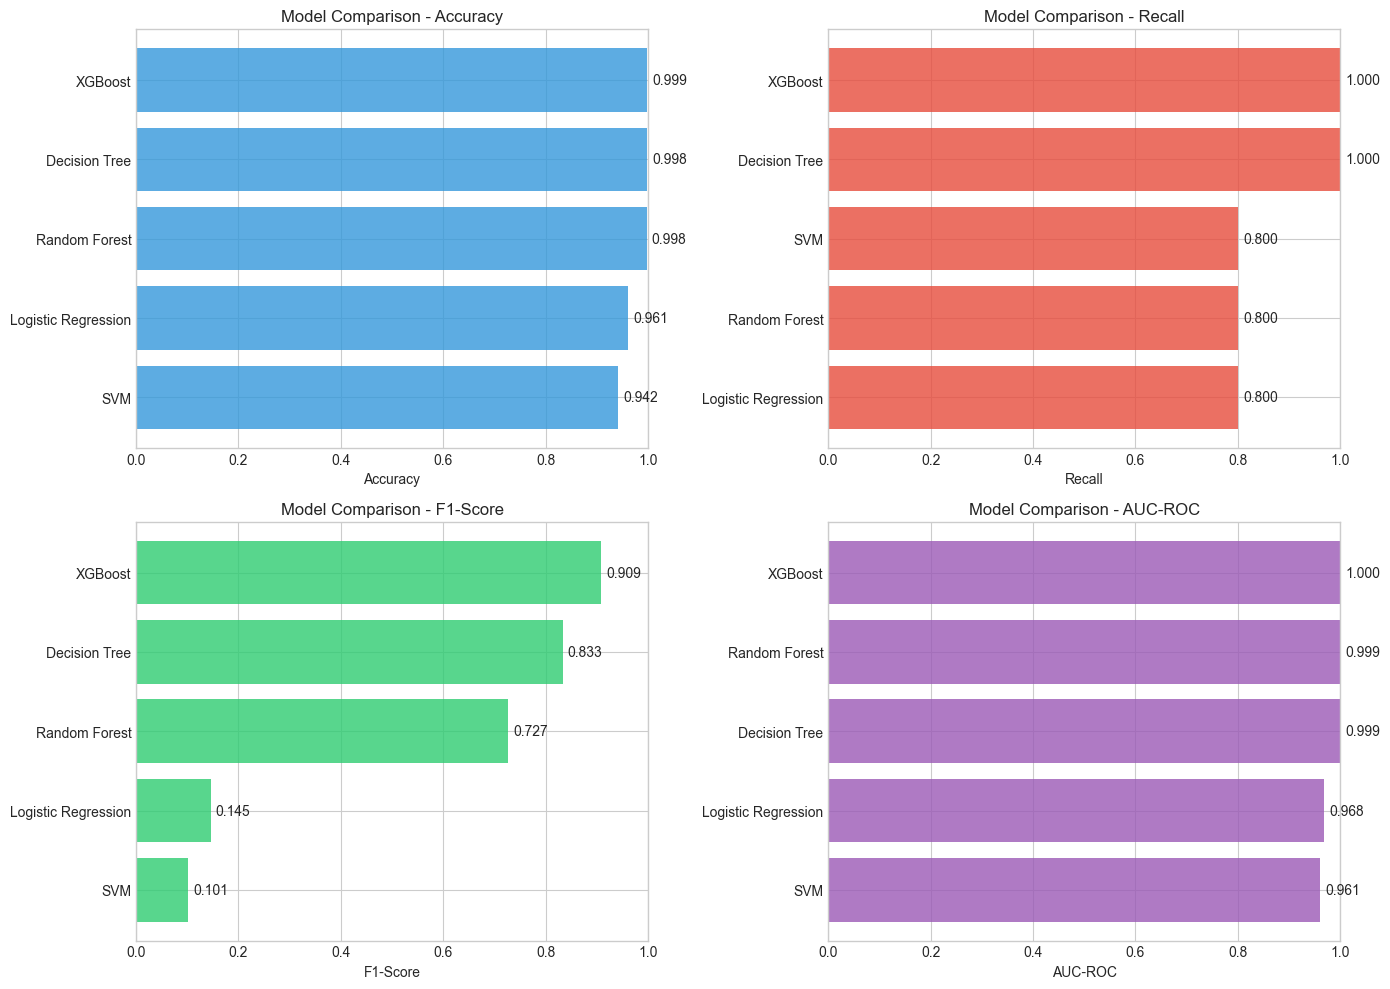

In [30]:
# Set up visualization style
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Model Comparison Bar Chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Recall', 'F1-Score', 'AUC-ROC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx // 2, idx % 2]
    sorted_df = results_df.sort_values(by=metric, ascending=True)
    ax.barh(sorted_df['Model'], sorted_df[metric], color=color, alpha=0.8)
    ax.set_xlabel(metric)
    ax.set_title(f'Model Comparison - {metric}')
    ax.set_xlim(0, 1)
    for i, v in enumerate(sorted_df[metric]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()

plt.show()


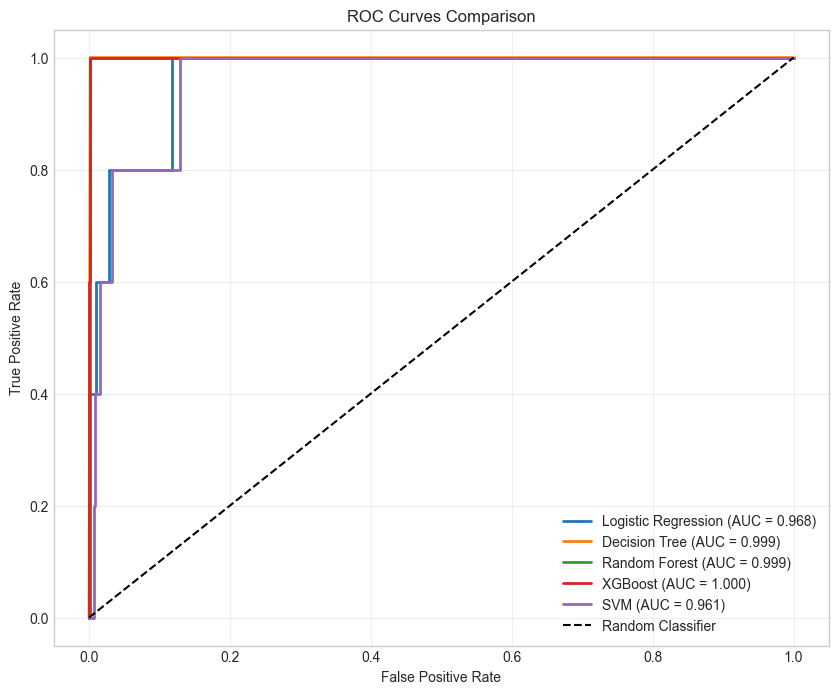

In [31]:
# 2. ROC Curves
plt.figure(figsize=(10, 8))

for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()


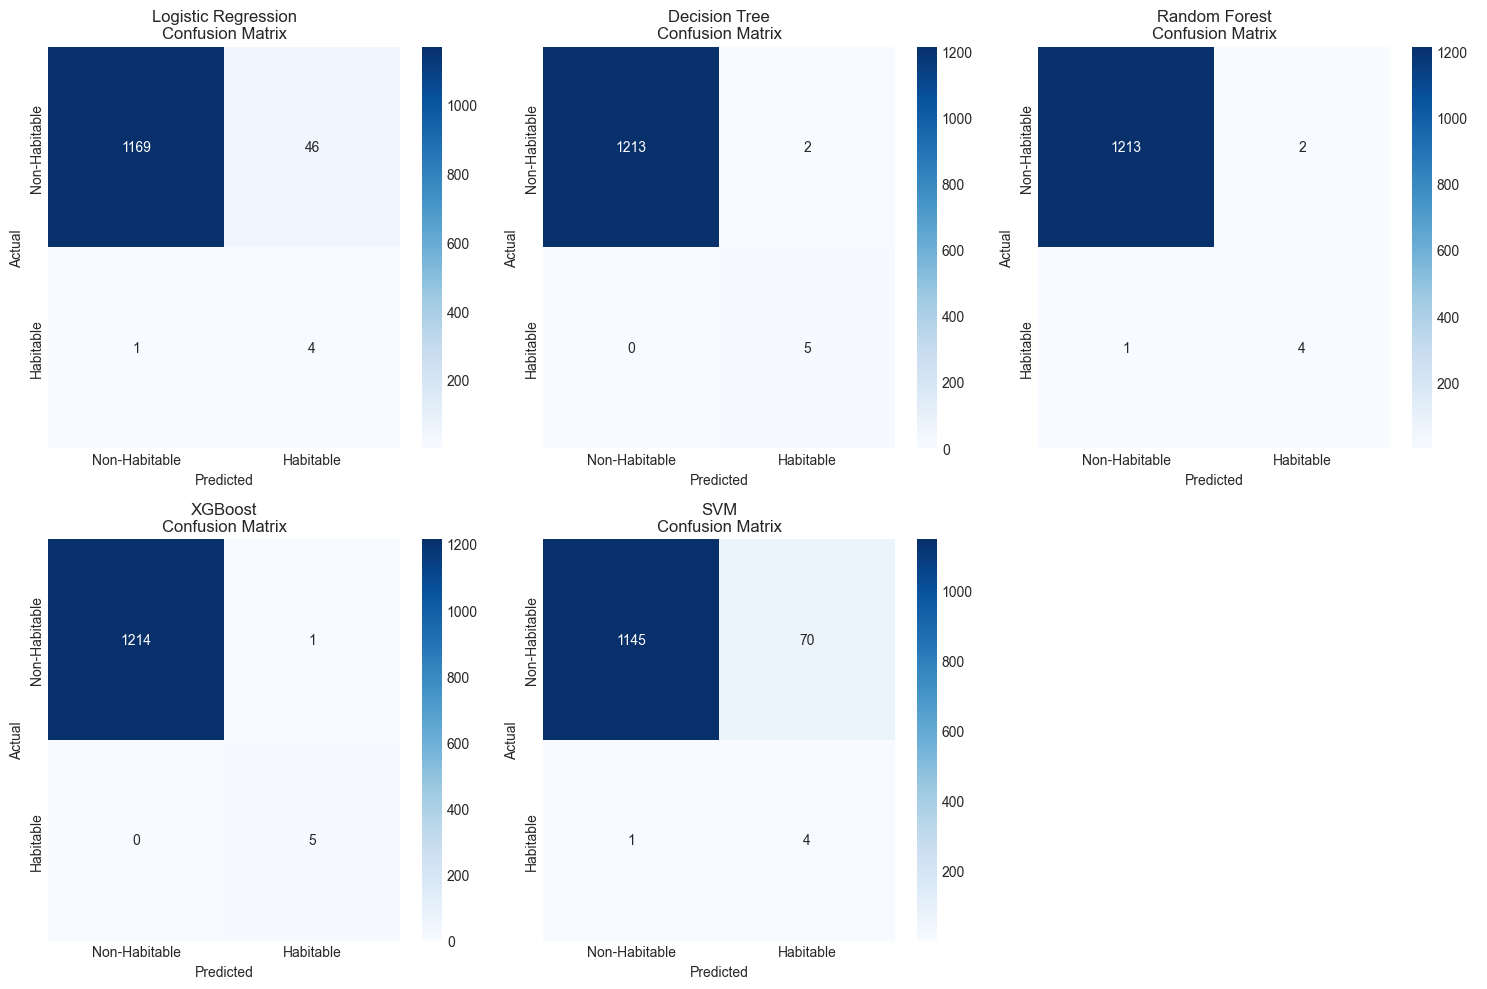

In [32]:
# 3. Confusion Matrix Heatmaps
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Non-Habitable', 'Habitable'],
                yticklabels=['Non-Habitable', 'Habitable'])
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

# Remove empty subplot
axes[-1].axis('off')

plt.tight_layout()

plt.show()

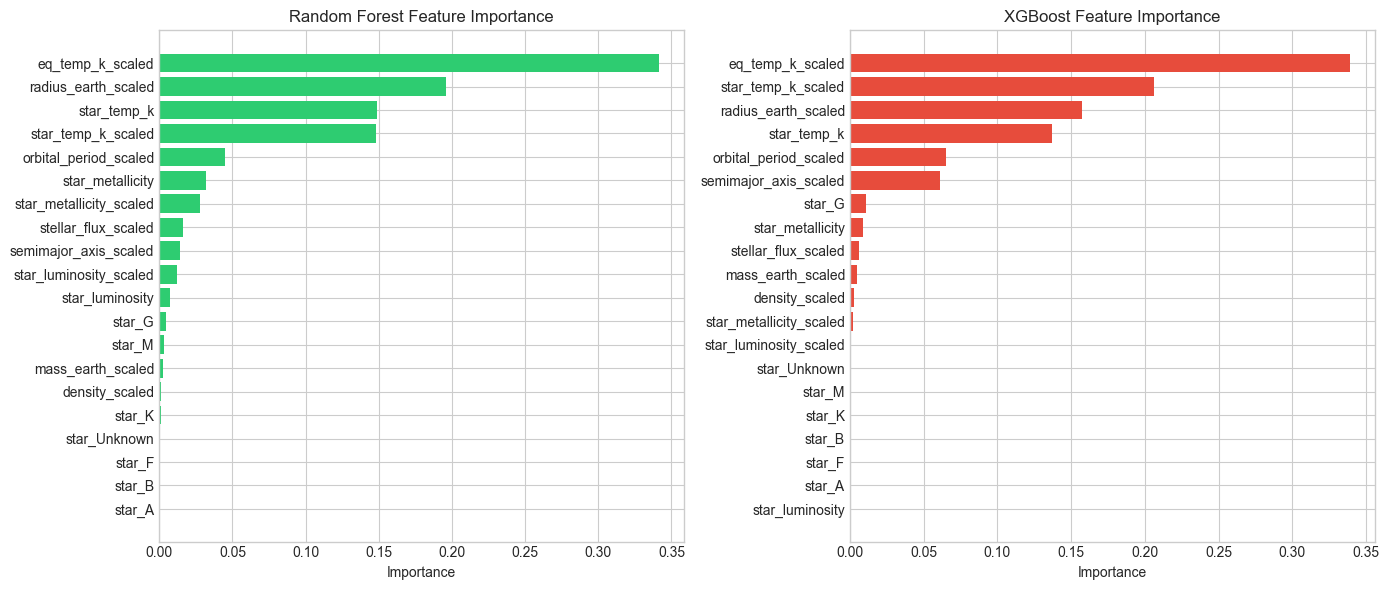

In [33]:
# 4. Feature Importance (Random Forest & XGBoost)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': trained_models['Random Forest'].feature_importances_
}).sort_values(by='Importance', ascending=True)

axes[0].barh(rf_importance['Feature'], rf_importance['Importance'], color='#2ecc71')
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance')

# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': trained_models['XGBoost'].feature_importances_
}).sort_values(by='Importance', ascending=True)

axes[1].barh(xgb_importance['Feature'], xgb_importance['Importance'], color='#e74c3c')
axes[1].set_title('XGBoost Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()

plt.show()


## 12. Ensemble Model (Voting Classifier)

In [34]:
# Create ensemble model with the best individual models
ensemble = VotingClassifier(
    estimators=[
        ('xgb', trained_models['XGBoost']),
        ('rf', trained_models['Random Forest']),
        ('lr', trained_models['Logistic Regression'])
    ],
    voting='soft',
    n_jobs=-1
)

# Train ensemble on scaled data
ensemble.fit(X_train_scaled, y_train_res)
y_pred_ensemble = ensemble.predict(X_test_scaled)
y_prob_ensemble = ensemble.predict_proba(X_test_scaled)[:, 1]

# Evaluate ensemble
print("Ensemble Model Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ensemble):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_ensemble):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_ensemble):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_ensemble):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_ensemble)}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble, target_names=['Non-Habitable', 'Habitable']))

Ensemble Model Results:
Accuracy: 0.9992
Recall: 1.0000
F1-Score: 0.9091
AUC-ROC: 0.9993

Confusion Matrix:
[[1214    1]
 [   0    5]]

Classification Report:
               precision    recall  f1-score   support

Non-Habitable       1.00      1.00      1.00      1215
    Habitable       0.83      1.00      0.91         5

     accuracy                           1.00      1220
    macro avg       0.92      1.00      0.95      1220
 weighted avg       1.00      1.00      1.00      1220



## 13. Saving All Models

In [35]:
# Save all trained models
for name, model in trained_models.items():
    filename = f"{name.replace(' ', '_').lower()}_model.pkl"
    filepath = os.path.join(MODELS_PATH, filename)
    joblib.dump(model, filepath)
    print(f"Saved: {filename}")

# Save ensemble model
joblib.dump(ensemble, os.path.join(MODELS_PATH, 'ensemble_model.pkl'))
print("Saved: ensemble_model.pkl")

# Save results
results_df.to_csv(os.path.join(MODELS_PATH, 'model_results.csv'), index=False)
print("Saved: model_results.csv")

print(f"\nAll models saved to: {MODELS_PATH}")

Saved: logistic_regression_model.pkl
Saved: decision_tree_model.pkl
Saved: random_forest_model.pkl
Saved: xgboost_model.pkl
Saved: svm_model.pkl
Saved: ensemble_model.pkl
Saved: model_results.csv

All models saved to: c:\Users\konal\OneDrive\Documents\GitHub\B13-ExoHabitAI\models


## 14. Summary and Conclusions

In [36]:
# Final Summary
print("="*60)
print("EXOPLANET HABITABILITY CLASSIFICATION - FINAL SUMMARY")
print("="*60)

print("\n📊 Dataset Information:")
print(f"   - Total samples: {len(df)}")
print(f"   - Features used: {len(X_cols)}")
print(f"   - Class distribution: {dict(y.value_counts())}")

print("\n🏆 Model Performance (sorted by F1-Score):")
print(results_df.to_string(index=False))

print("\n🎯 Best Model:")
print(f"   - Model: {best_model_name}")
print(f"   - F1-Score: {results_df[results_df['Model']==best_model_name]['F1-Score'].values[0]:.4f}")

print("\n💾 Saved Models:")
print(f"   - All individual models")
print(f"   - Ensemble model")
print(f"   - Scaler")
print(f"   - Results CSV")

print("\n📈 Saved Visualizations:")
print(f"   - Model comparison chart")
print(f"   - ROC curves")
print(f"   - Confusion matrices")
print(f"   - Feature importance plots")

print("\n🔧 Regularization Techniques Used:")
print("   - Mild SMOTE (30% of majority class)")
print("   - L2 regularization in Logistic Regression (C=0.1)")
print("   - Depth limits and pruning in Decision Tree/Random Forest")
print("   - XGBoost: L1/L2 regularization, subsampling")
print("   - 5-fold cross-validation for robust evaluation")

print("\n" + "="*60)
print("Pipeline completed successfully!")
print("="*60)

EXOPLANET HABITABILITY CLASSIFICATION - FINAL SUMMARY

📊 Dataset Information:
   - Total samples: 6100
   - Features used: 20
   - Class distribution: {0: np.int64(6073), 1: np.int64(27)}

🏆 Model Performance (sorted by F1-Score):
              Model  Accuracy  Recall  F1-Score  AUC-ROC  CV_F1_Mean  CV_F1_Std
            XGBoost  0.999180     1.0  0.909091 0.999671    0.997945   0.001998
      Decision Tree  0.998361     1.0  0.833333 0.999177    0.998630   0.001281
      Random Forest  0.997541     0.8  0.727273 0.999342    0.998630   0.001281
Logistic Regression  0.961475     0.8  0.145455 0.968395    0.920246   0.011681
                SVM  0.941803     0.8  0.101266 0.961317    0.905906   0.009182

🎯 Best Model:
   - Model: XGBoost
   - F1-Score: 0.9091

💾 Saved Models:
   - All individual models
   - Ensemble model
   - Scaler
   - Results CSV

📈 Saved Visualizations:
   - Model comparison chart
   - ROC curves
   - Confusion matrices
   - Feature importance plots

🔧 Regularizatio